# Statistics Project

To analyze customer behavior using statistical and mathematical tools in Python, to
identify factors affecting customer retention and churn.

In [13]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
import statsmodels.api as sm
import scipy.stats as stats

In [14]:
df=pd.read_csv("customer_behavior.csv")
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [4]:
df.shape

(5000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [6]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


In [14]:
df["PurchaseAmount"].value_counts()

PurchaseAmount
0.00       102
1018.78      3
1141.96      2
345.01       2
1062.19      2
          ... 
1134.65      1
233.70       1
295.39       1
1733.22      1
1392.74      1
Name: count, Length: 4687, dtype: int64

In [15]:
df.isnull().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

In [16]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [17]:
df[df.duplicated()]

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup


In [10]:
df["PurchaseAmount"].mean()

np.float64(1003.9506701030928)

In [8]:
df["PurchaseAmount"].median()

998.0799999999999

In [18]:
df["PurchaseAmount"].fillna(df["PurchaseAmount"].median(),inplace=True)

In [19]:
df.isnull().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount       0
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [22]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [23]:
df["Gender"].mode()[0]

'Male'

In [ ]:
df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)


In [ ]:
df["Region"].unique()

array(['South', 'West', 'North', 'East', nan], dtype=object)

In [27]:
df["Region"].mode()[0]

'South'

In [29]:
df["Region"].fillna(df["Region"].mode()[0],inplace=True)

In [30]:
df["ProductCategory"].unique()

array(['Fashion', 'Electronics', 'Grocery', nan], dtype=object)

In [31]:
df["ProductCategory"].mode()[0]

'Grocery'

In [33]:
df["ProductCategory"].fillna(df["ProductCategory"].mode()[0],inplace=True)

In [34]:
df["Churn"].unique()

array(['No', 'Yes', nan], dtype=object)

In [35]:
df["Churn"].mode()[0]

'No'

In [36]:
df["Churn"].fillna(df["Churn"].mode()[0],inplace=True)

In [37]:
df["CampaignGroup"].unique()

array(['A', 'B', nan], dtype=object)

In [38]:
df["CampaignGroup"].mode()[0]

'A'

In [39]:
df["CampaignGroup"].fillna(df["CampaignGroup"].mode()[0],inplace=True)

In [40]:
df.isnull().sum()

CustomerID         0
Gender             0
Region             0
PurchaseAmount     0
ProductCategory    0
Churn              0
CampaignGroup      0
dtype: int64

1. What is the average, median, and mode of PurchaseAmount?

In [54]:
c= df["PurchaseAmount"].mean()
print("Average =",c)
k= df["PurchaseAmount"].median()
print("\nMedain =",k)
y= df["PurchaseAmount"].mode()
print("\nMode =",y)

Average = 1003.77455

Medain = 998.0799999999999

Mode = 0    998.08
Name: PurchaseAmount, dtype: float64


2. Are there any outliers in the PurchaseAmount data?

In [55]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,5000.000000
mean,3500.500000,1003.774550
std,1443.520003,474.825946
min,1001.000000,0.000000
25%,2250.750000,686.395000
50%,3500.500000,998.080000
75%,4750.250000,1316.155000
max,6000.000000,2688.880000


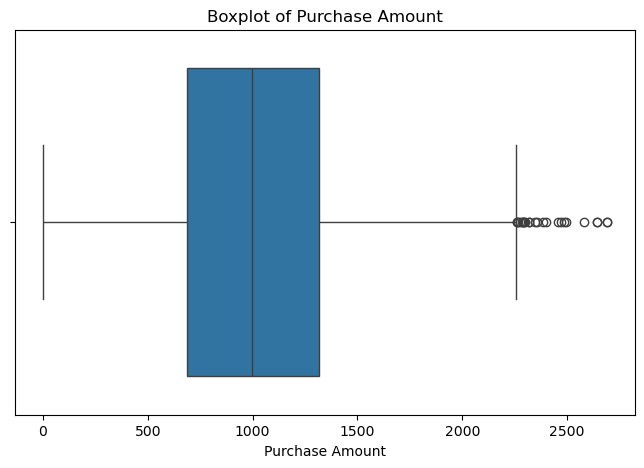

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['PurchaseAmount'])

plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

In [57]:
Q1 =df["PurchaseAmount"].quantile(0.25)
Q3 =df["PurchaseAmount"].quantile(0.75)
IQR= Q1-Q3
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)


Q1: 686.395
Q3: 1316.155
IQR: -629.76


In [58]:
Left=Q1-1.5*IQR
Right=Q3+1.5*IQR
print("Left:",Left)
print("Right:",Right)

Left: 1631.0349999999999
Right: 371.515


In [63]:
outliers = df[
    (df['PurchaseAmount'] < Left) |
    (df['PurchaseAmount'] > Right)
]

print(outliers)

      CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
0           1001    Male  South          256.07         Fashion    No   
1           1002  Female  South          998.08     Electronics   Yes   
2           1003  Female   West         1194.41         Fashion    No   
3           1004  Female  South          413.06         Grocery    No   
4           1005    Male   West         1556.32         Fashion   Yes   
...          ...     ...    ...             ...             ...   ...   
4995        5996  Female   West         1497.00     Electronics   Yes   
4996        5997    Male   West          978.87         Fashion   Yes   
4997        5998    Male   West          906.93         Fashion    No   
4998        5999  Female  South          375.67         Fashion    No   
4999        6000  Female  North         1392.74         Grocery   Yes   

     CampaignGroup  
0                A  
1                B  
2                A  
3                A  
4                A

In [64]:
print("Number of outliers:", len(outliers))

Number of outliers: 5000


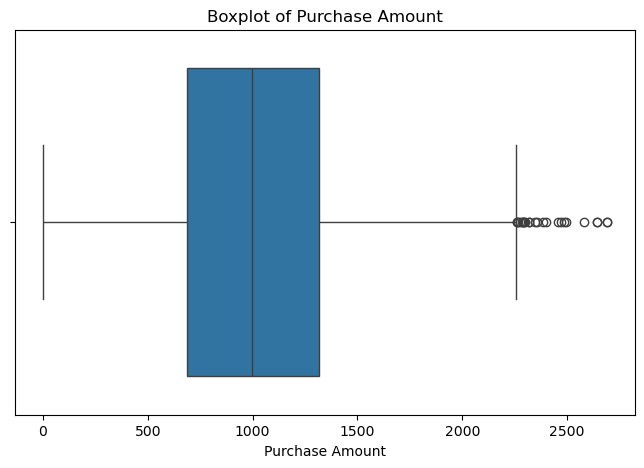

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['PurchaseAmount'])

plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [70]:
skewness=df["PurchaseAmount"].skew()
kurtosis=df["PurchaseAmount"].kurt()
print("\nskewness=",skewness)
print("\nkurtosis=",kurtosis)


skewness= 0.10883141246252831

kurtosis= -0.17665360565282562


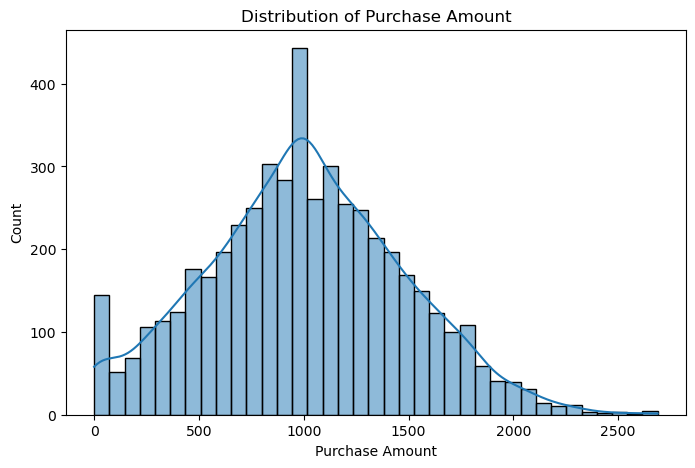

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(df['PurchaseAmount'], kde=True)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

4. Is there a significant difference in spending between male and female
customers?

In [73]:
df.columns

Index(['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory',
       'Churn', 'CampaignGroup'],
      dtype='object')

In [75]:
gender_mean=df.groupby("Gender")["PurchaseAmount"].mean()
gender_mean

Gender
Female     988.185174
Male      1018.692759
Name: PurchaseAmount, dtype: float64

In [81]:
male = df[df['Gender'] == 'Male']['PurchaseAmount']
female = df[df['Gender'] == 'Female']['PurchaseAmount']
t_stat, p_value =ttest_ind(male, female, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.271227153260738
P-value: 0.023175721316218083


In [82]:
if p_value < 0.05:
    print("Reject H0: There is a significant difference in spending.")
else:
    print("Fail to reject H0: There is no significant difference in spending.")

Reject H0: There is a significant difference in spending.


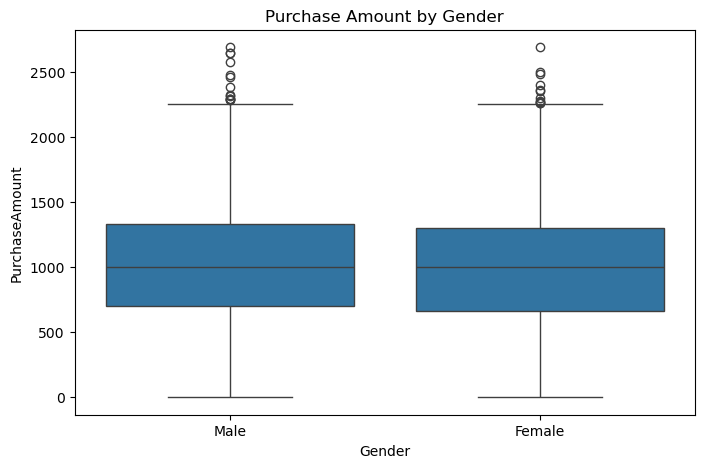

In [83]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Gender', y='PurchaseAmount')

plt.title("Purchase Amount by Gender")

plt.show()

5. Is there a relationship between ProductCategory and customer churn?

In [84]:
df.columns

Index(['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory',
       'Churn', 'CampaignGroup'],
      dtype='object')

In [86]:
df["ProductCategory"].unique()

array(['Fashion', 'Electronics', 'Grocery'], dtype=object)

In [87]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [85]:
contingency_table = pd.crosstab(
    df['ProductCategory'],
    df['Churn']
)

print(contingency_table)

Churn              No  Yes
ProductCategory           
Electronics       862  541
Fashion           916  607
Grocery          1279  795


In [89]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square: 0.9320029725740938
P-value: 0.6275063513920858
Degrees of freedom: 2


In [90]:
if p_value < 0.05:
    print("There is a significant relationship between ProductCategory and Churn.")
else:
    print("There is no significant relationship between ProductCategory and Churn.")

There is no significant relationship between ProductCategory and Churn.


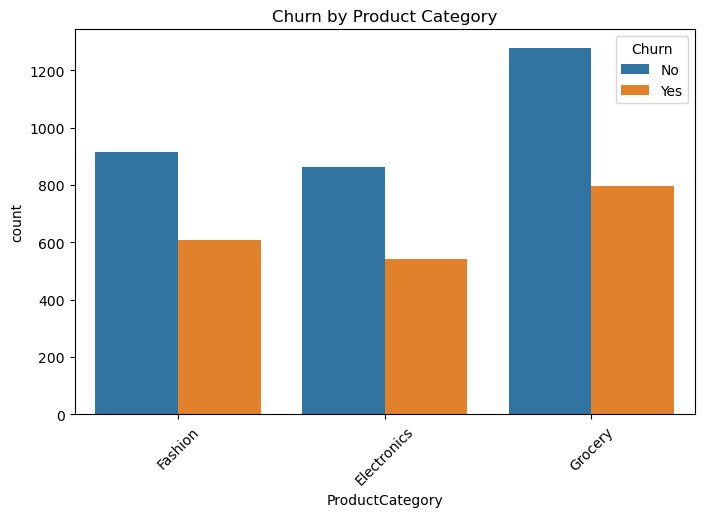

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ProductCategory',
    hue='Churn'
)

plt.title("Churn by Product Category")
plt.xticks(rotation=45)

plt.show()

6. Does PurchaseAmount vary significantly across different regions?

In [6]:
model = ols(
    'PurchaseAmount ~ C(Region)',
    data=df
).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df         F    PR(>F)
C(Region)  2.717404e+05     3.0  0.389668  0.760453
Residual   1.086726e+09  4675.0       NaN       NaN


In [9]:
p_value = anova_table['PR(>F)'][0]
if p_value < 0.05:
    print("PurchaseAmount varies significantly across regions.")
else:
    print("There is no significant difference in PurchaseAmount across regions.")

There is no significant difference in PurchaseAmount across regions.


C:\Users\shaheer\AppData\Local\Temp\ipykernel_28688\1390433359.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


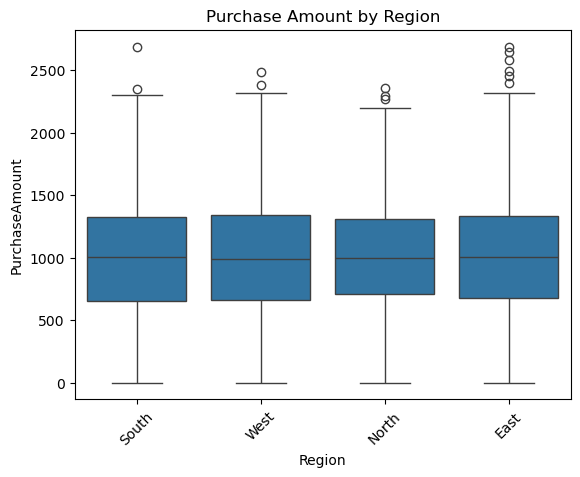

In [10]:
sns.boxplot(data=df, x='Region', y='PurchaseAmount')

plt.title("Purchase Amount by Region")
plt.xticks(rotation=45)
plt.show()

In [ ]:
region_mean = df.groupby('Region')['PurchaseAmount'].mean()
print(region_mean)

Region
East     1009.645979
North    1012.475202
South     998.093141
West      995.309447
Name: PurchaseAmount, dtype: float64


In [95]:
groups = [
    group['PurchaseAmount'].values
    for name, group in df.groupby('Region')
]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.3865658263408036
P-value: 0.762690305503975


In [96]:
if p_value < 0.05:
    print("Reject H0: PurchaseAmount differs significantly across regions.")
else:
    print("Fail to reject H0: No significant difference across regions.")

Fail to reject H0: No significant difference across regions.


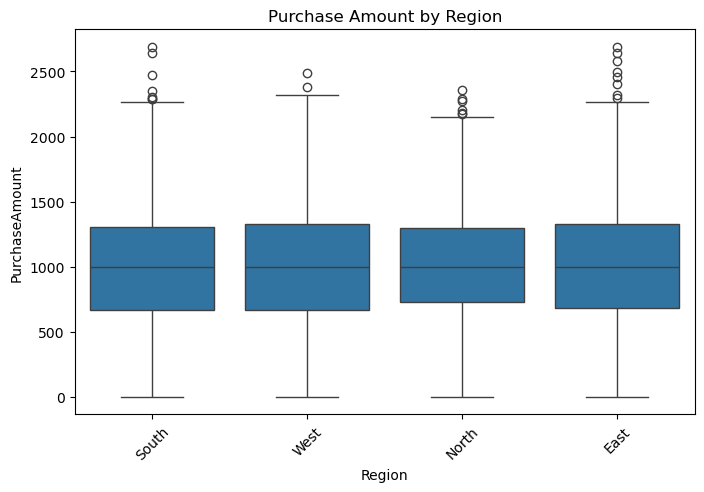

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Region',
    y='PurchaseAmount'
)

plt.title("Purchase Amount by Region")

plt.xticks(rotation=45)

plt.show()

7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?

In [101]:
df["CampaignGroup"].unique()

array(['A', 'B'], dtype=object)

In [98]:
campaign_mean = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print(campaign_mean)

CampaignGroup
A    1012.250984
B     994.435864
Name: PurchaseAmount, dtype: float64


In [102]:
better_campaign = campaign_mean.idxmax()
better_value = campaign_mean.max()
print("Better Campaign:", better_campaign)
print("Average Purchase Amount:", better_value)

Better Campaign: A
Average Purchase Amount: 1012.2509843571156


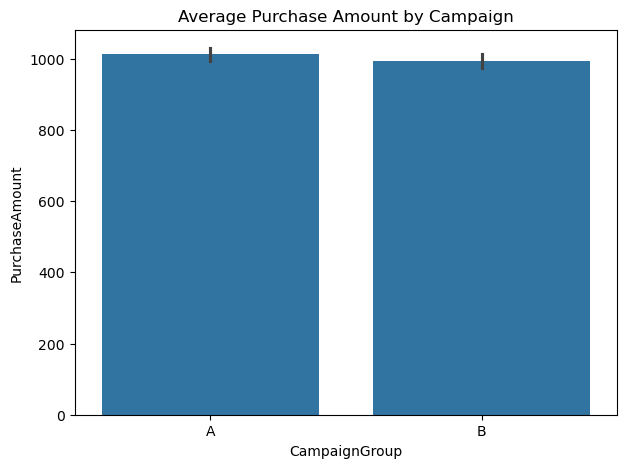

In [103]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='CampaignGroup',
    y='PurchaseAmount'
)

plt.title("Average Purchase Amount by Campaign")

plt.show()

8. Can we assume PurchaseAmount follows a normal distribution?

In [15]:
stat, p_value = stats.shapiro(df['PurchaseAmount'])

print("Shapiro-Wilk Statistic:", stat)
print("P-value:", p_value)

Shapiro-Wilk Statistic: nan
P-value: nan


In [11]:
if p_value < 0.05:
    print("PurchaseAmount does not follow a normal distribution.")
else:
    print("PurchaseAmount can be considered approximately normally distributed.")

PurchaseAmount can be considered approximately normally distributed.


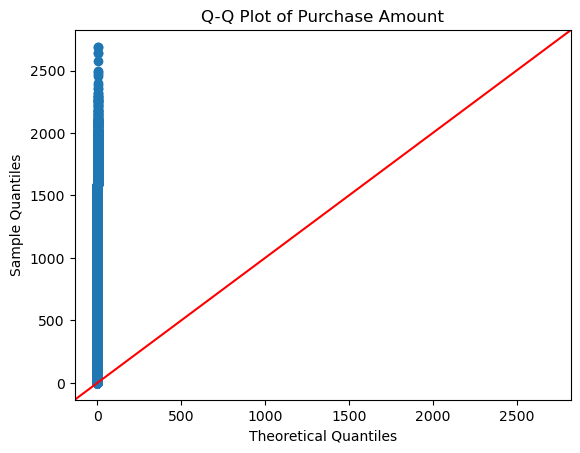

In [16]:
sm.qqplot(df['PurchaseAmount'], line='45')

plt.title("Q-Q Plot of Purchase Amount")
plt.show()

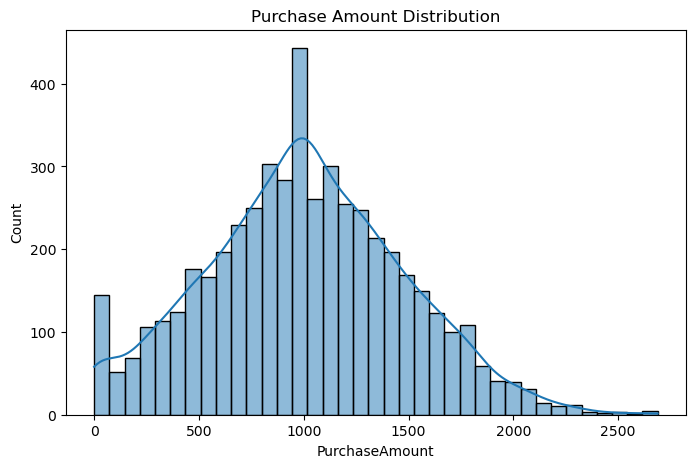

In [105]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['PurchaseAmount'],
    kde=True
)

plt.title("Purchase Amount Distribution")

plt.show()

9. What insights can we gain by applying the Central Limit Theorem?


In [18]:
df.shape

(5000, 7)

In [22]:
sample_means = []

for i in range(1000):
    sample = df['PurchaseAmount'].sample(n=30, replace=True)
    sample_means.append(sample.mean())

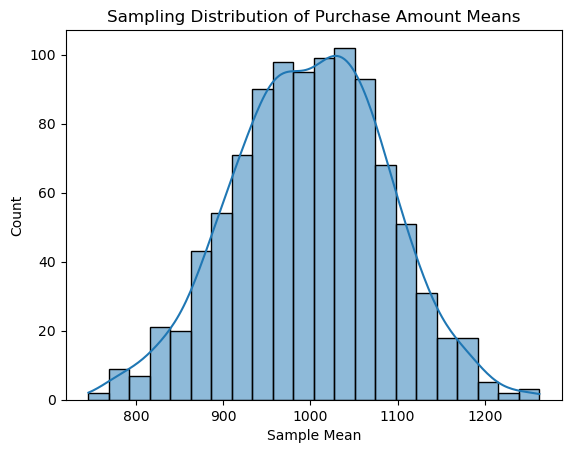

In [23]:
sns.histplot(sample_means, kde=True)

plt.title("Sampling Distribution of Purchase Amount Means")
plt.xlabel("Sample Mean")
plt.show()

In [24]:
print("Mean of sample means:", np.mean(sample_means))
print("Population mean:", df['PurchaseAmount'].mean())

Mean of sample means: 999.8023802088248
Population mean: 1003.9506701030928


10.What is the 95% confidence interval for the average PurchaseAmount?

In [27]:
data = df['PurchaseAmount'].dropna()

mean = data.mean()
std = data.std()
n = len(data)
standard_error = std / np.sqrt(n)
t_critical = stats.t.ppf(0.975, df=n-1)
margin_error = t_critical * standard_error

lower = mean - margin_error
upper = mean + margin_error

print("Mean:", mean)
print("95% Confidence Interval:", lower, upper)

Mean: 1003.9506701030928
95% Confidence Interval: 990.3789594609216 1017.522380745264


In [28]:
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print("95% Confidence Interval:", confidence_interval)

95% Confidence Interval: (np.float64(990.3789594609216), np.float64(1017.522380745264))
